# Autoencoders, VAEs, and Latent Representations

The third state-of-the-art generative architecture, after the
[GAN and the diffusion model](gansdiffusion.ipynb), is the **variational
autoencoder (VAE)**. It grows out of dimensionality reduction, so this page
also closes a loop begun in the
[unsupervised learning unit](../UnsupervisedML/dimensionalityreduction.ipynb).
We will:

- Review **dimensionality reduction** and place deep learning methods among
  the linear ones.
- Build an **autoencoder**: a neural network that learns a low dimensional
  representation of its own input.
- See what a **latent space** buys us: denoising, generation, semi-supervised
  learning, anomaly detection.
- Define the **variational autoencoder** and why its latent space is smoother.
- Survey scientific uses of latent representations, including
  **convective organization**.

## Dimensionality reduction, revisited

Dimensionality reduction techniques reduce the number of features in a dataset
while retaining the essential information, for visualization, analysis,
feature engineering, or model performance. Data often live on a lower
dimensional manifold: however many variables we record, the system has limited
degrees of freedom, and only so many states actually occur. The main method
families:

- **Projection methods** transform the data *linearly* to lower dimensions:
  principal component analysis (PCA), which for spatio-temporal climate data
  goes by the name empirical orthogonal function (EOF) analysis.
- **Manifold learning methods** capture nonlinear structure (t-SNE, UMAP,
  etc.).
- **Deep learning methods** transform the data *nonlinearly* using a neural
  network: autoencoders and variational autoencoders, today's subject.

Recall what PCA does: it finds the directions of greatest variance and
projects onto them. Here is the digits dataset (1797 images of handwritten
digits, 8 by 8 pixels, so 64 features) projected onto its first two principal
components.

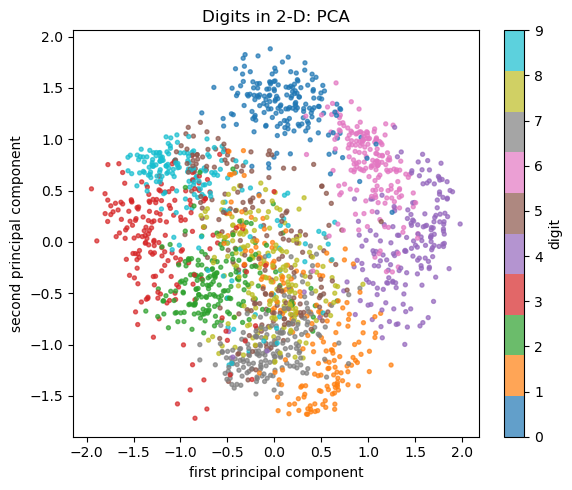

variance explained by 2 components: 0.29


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA

rng = np.random.default_rng(0)

digits = load_digits()
Xd = digits.data / 16.0          # scale pixel values to [0, 1]
yd = digits.target

pca2 = PCA(n_components=2).fit(Xd)
Zp = pca2.transform(Xd)

plt.figure(figsize=(6, 5))
sc = plt.scatter(Zp[:, 0], Zp[:, 1], c=yd, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(sc, label="digit")
plt.xlabel("first principal component"); plt.ylabel("second principal component")
plt.title("Digits in 2-D: PCA")
plt.tight_layout(); plt.show()

print(f"variance explained by 2 components: {pca2.explained_variance_ratio_.sum():.2f}")

Two linear components separate a few digits (0s and 6s hold together) but most
classes overlap heavily, and they capture under a third of the variance. A
linear projection is simply not flexible enough for images. That is the
opening for a neural network.

## Autoencoders

An **autoencoder** is nonlinear dimensionality reduction with neural networks.
It has two halves:

- An **encoder** network takes the input (here 64 pixels) and compresses it
  through progressively narrower layers down to a small **bottleneck**, the
  *latent representation*: here just 2 numbers.
- A **decoder** network takes the latent representation and tries to
  reconstruct the original input from it.

The two are trained *together* as one network whose training target is its own
input: a supervised learning setup where the loss is the reconstruction error.
The bottleneck is what makes it interesting: to reconstruct 64 pixels from 2
numbers, the network must discover what actually varies across the dataset.
Unlike PCA, the encoding is not restricted to directions of greatest variance
or to linear maps; it is whatever nonlinear representation the data support.
Either half can be any architecture we have seen (dense, CNN for images, RNN
for sequences), chosen to match the input type.

We can build one with `MLPRegressor` by making the target equal to the input
and giving the hidden layers an hourglass shape, 64 to 2 to 64.

In [2]:
from sklearn.neural_network import MLPRegressor

ae = MLPRegressor(hidden_layer_sizes=(64, 2, 64), activation="tanh",
                  max_iter=2000, tol=1e-6, random_state=0)
ae.fit(Xd, Xd)                    # the target IS the input

def encode(X):
    "run the first two layers of the trained network"
    h = np.tanh(X @ ae.coefs_[0] + ae.intercepts_[0])
    return np.tanh(h @ ae.coefs_[1] + ae.intercepts_[1])

def decode(Z):
    "run the last two layers of the trained network"
    h = np.tanh(Z @ ae.coefs_[2] + ae.intercepts_[2])
    return np.clip(h @ ae.coefs_[3] + ae.intercepts_[3], 0, 1)

Z = encode(Xd)
recon_ae = decode(Z)
recon_pca = pca2.inverse_transform(Zp)

mse_ae = ((recon_ae - Xd) ** 2).mean()
mse_pca = ((recon_pca - Xd) ** 2).mean()
print(f"reconstruction MSE through a 2-D bottleneck:")
print(f"  autoencoder: {mse_ae:.4f}")
print(f"  PCA:         {mse_pca:.4f}")

reconstruction MSE through a 2-D bottleneck:
  autoencoder: 0.0326
  PCA:         0.0524


Squeezed through the same 2 number bottleneck, the autoencoder reconstructs
the images with clearly lower error than PCA: the nonlinearity is doing real
work. Seeing the reconstructions makes the comparison tangible.

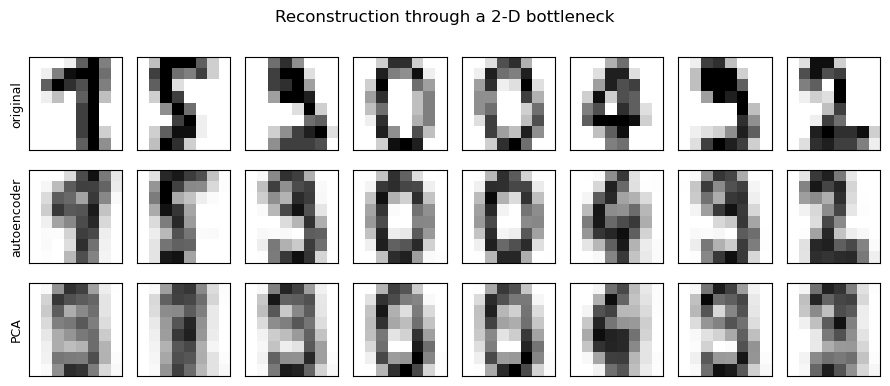

In [3]:
fig, axes = plt.subplots(3, 8, figsize=(9, 4))
show = rng.choice(len(Xd), 8, replace=False)
for col, i in enumerate(show):
    for row, (img, label) in enumerate([(Xd[i], "original"),
                                        (recon_ae[i], "autoencoder"),
                                        (recon_pca[i], "PCA")]):
        ax = axes[row, col]
        ax.imshow(img.reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
fig.suptitle("Reconstruction through a 2-D bottleneck")
plt.tight_layout(); plt.show()

Both reconstructions are blurry (2 numbers cannot hold 64 pixels of detail),
but the autoencoder's outputs are recognizable digits far more often than
PCA's. Now look at *where* the encoder puts each image in its 2-D latent
space, side by side with the PCA projection.

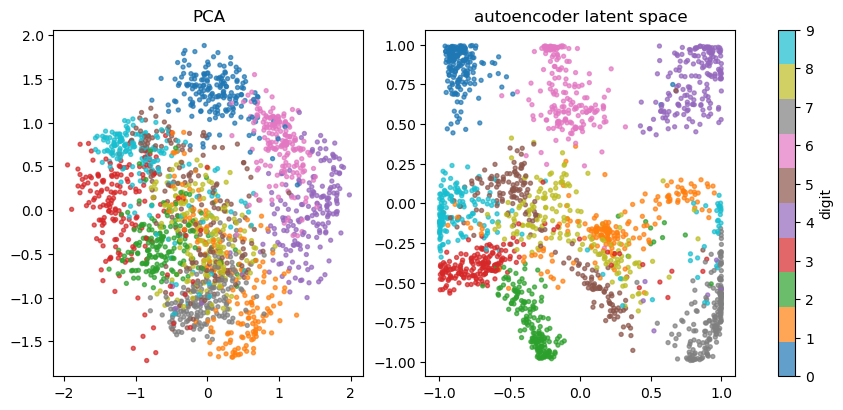

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=False)
for ax, (Zi, name) in zip(axes, [(Zp, "PCA"), (Z, "autoencoder latent space")]):
    sc = ax.scatter(Zi[:, 0], Zi[:, 1], c=yd, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(name)
fig.colorbar(sc, ax=axes, label="digit")
plt.show()

The autoencoder was never told the labels, yet its latent space groups the
digit classes into more distinct clumps than PCA manages. Images that are
similar sit near each other, which is exactly what makes latent spaces useful:
clustering, similarity search, and the applications below all run on this
geometry.

### Denoising

Because the bottleneck keeps only the most representative structure in the
data, an autoencoder can be turned into a noise remover. The clean recipe is
the **denoising autoencoder**: corrupt each training input with random noise,
but keep the *clean* image as the training target. The network then cannot
succeed by memorizing pixels; it must learn what digits look like underneath
the noise. (Simply round-tripping noisy images through the 2-D autoencoder
above does not work: its reconstructions are too coarse to beat the noise
pixel for pixel, so here we allow the bottleneck 16 dimensions.)

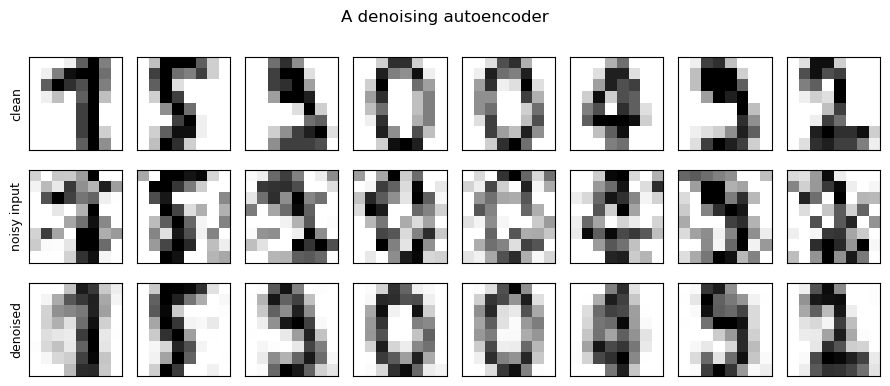

MSE to the clean image, noisy input:     0.0517
MSE to the clean image, denoised output: 0.0205


In [5]:
X_noisy_train = np.clip(Xd + 0.30 * rng.standard_normal(Xd.shape), 0, 1)
dae = MLPRegressor(hidden_layer_sizes=(64, 16, 64), activation="tanh",
                   max_iter=2000, tol=1e-6, random_state=0)
dae.fit(X_noisy_train, Xd)          # noisy input, CLEAN target

X_noisy = np.clip(Xd + 0.30 * rng.standard_normal(Xd.shape), 0, 1)  # fresh noise
denoised = np.clip(dae.predict(X_noisy), 0, 1)

fig, axes = plt.subplots(3, 8, figsize=(9, 4))
for col, i in enumerate(show):
    for row, (img, label) in enumerate([(Xd[i], "clean"),
                                        (X_noisy[i], "noisy input"),
                                        (denoised[i], "denoised")]):
        ax = axes[row, col]
        ax.imshow(img.reshape(8, 8), cmap="gray_r", vmin=0, vmax=1)
        ax.set_xticks([]); ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(label, fontsize=9)
fig.suptitle("A denoising autoencoder")
plt.tight_layout(); plt.show()

print(f"MSE to the clean image, noisy input:     {((X_noisy - Xd) ** 2).mean():.4f}")
print(f"MSE to the clean image, denoised output: {((denoised - Xd) ** 2).mean():.4f}")

The denoised output is more than twice as close to the clean image as the
noisy input it was given, on noise the network never saw during training. The
same trick, predicting the clean signal from a corrupted version of it, is
also the training objective at the heart of the diffusion models on the
[previous page](gansdiffusion.ipynb).

### Generating new samples

The decoder does not care whether its input came from the encoder. Feed it
*any* point in the latent space and it will render an image. Sweeping a grid
across the latent space maps out the **latent manifold**: what the model
believes the data look like everywhere in its coordinate system.

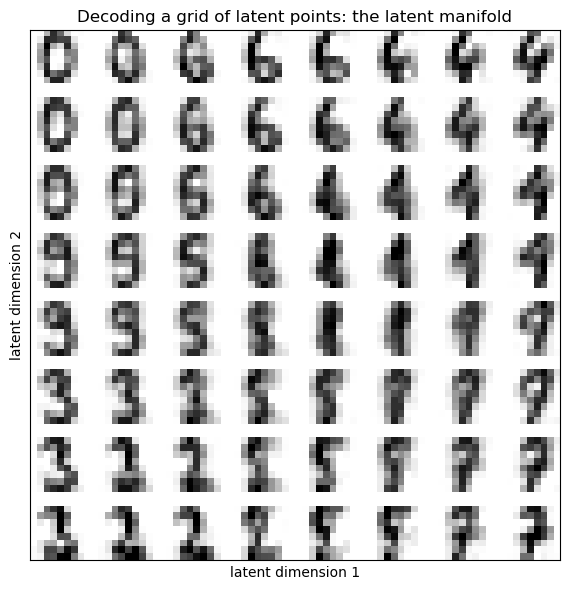

In [6]:
g1 = np.linspace(*np.percentile(Z[:, 0], [2, 98]), 8)
g2 = np.linspace(*np.percentile(Z[:, 1], [2, 98]), 8)
step = 8 + 2                       # 8 pixel tiles, 2 blank pixels between them
canvas = np.zeros((8 * step - 2, 8 * step - 2))
for r, z2 in enumerate(g2[::-1]):
    for c, z1 in enumerate(g1):
        img = decode(np.array([[z1, z2]]))[0].reshape(8, 8)
        canvas[r * step:r * step + 8, c * step:c * step + 8] = img

plt.figure(figsize=(6, 6))
plt.imshow(canvas, cmap="gray_r")
plt.xticks([]); plt.yticks([])
plt.xlabel("latent dimension 1"); plt.ylabel("latent dimension 2")
plt.title("Decoding a grid of latent points: the latent manifold")
plt.tight_layout(); plt.show()

Every tile is a **generated image**: none of these exact digits exists in the
training set. Neighboring tiles morph smoothly into one another, and the
clusters from the scatter plot reappear as regions of the grid that render
similar digits. But notice the seams: between clusters the decoder produces
smeared shapes that are not convincing digits. The plain autoencoder's latent
space has *holes*, regions no training image maps to, where the decoder was
never supervised. That weakness is what the variational autoencoder fixes.

### Semi-supervised learning

Latent spaces also help when labels are scarce, a constant condition in
environmental science, where labeling means expert time. Suppose we could
afford to label only 50 of the 1797 digit images. We can still encode *all*
of them, then classify unlabeled images by which labeled ones they sit near
in latent space.

In [7]:
from sklearn.neighbors import KNeighborsClassifier

rng_lab = np.random.default_rng(42)
labeled = rng_lab.choice(len(yd), 50, replace=False)
mask = np.ones(len(yd), bool)
mask[labeled] = False

for name, F in [("64 raw pixels", Xd), ("2-D PCA", Zp), ("2-D latent", Z)]:
    knn = KNeighborsClassifier(n_neighbors=3).fit(F[labeled], yd[labeled])
    acc = knn.score(F[mask], yd[mask])
    print(f"3-NN with 50 labels on {name:13s}: {acc:.1%} accuracy on the rest")

3-NN with 50 labels on 64 raw pixels: 75.4% accuracy on the rest
3-NN with 50 labels on 2-D PCA      : 51.1% accuracy on the rest
3-NN with 50 labels on 2-D latent   : 74.0% accuracy on the rest


With the same 50 labels, nearest neighbors in the autoencoder's 2 dimensions
(about 74 percent accuracy) classify far better than in PCA's 2 dimensions
(about 51 percent), and nearly match all 64 raw pixels (about 75 percent). Two
learned numbers per image retain most of what the 64 pixels know about digit
identity. (A fourth use, **anomaly detection**,
follows the same logic as on the [previous page](gansdiffusion.ipynb): points
that land far from everything else in latent space are candidates for
contamination, instrument error, or genuinely unusual events.)

## Variational autoencoders

The **variational autoencoder** keeps the encoder-bottleneck-decoder shape but
makes the encoding *probabilistic*. Instead of mapping an input to a single
latent point, the encoder outputs the parameters of a distribution (a mean and
a variance per latent dimension). During training a latent point is *sampled*
from that distribution, with random noise added, and the decoder must
reconstruct the input from the perturbed sample. The loss adds a second term
to the reconstruction error: the **KL divergence** between the encoder's
distribution and a standard Gaussian, which measures how far the learned
latent distribution strays from the Gaussian prior. Minimizing it pulls the
cloud of latent points toward a smooth Gaussian ball.

The effect is exactly what the latent manifold above was missing: the latent
space is **smoothed out**, with no holes, because every neighborhood gets
covered by some training sample's noise. Sampling any point from the Gaussian
prior and decoding it yields a plausible new sample, which is what makes the
VAE a genuinely *generative* model, effectively learning the underlying
distribution of the data rather than a fixed mapping. Classic VAE
visualizations of clothing images (Fashion-MNIST) show shirts, dresses, and
pants occupying their own regions of latent space, with interpolations between
them rendering plausible intermediate garments.

## Latent representations for scientific analysis

In science the samples we care about are not digits but fields and
observations, and the latent space becomes an instrument for analysis.

**Classifying convection in climate model output.** [Work by Mooers and
collaborators](https://arxiv.org/abs/2007.01444) encoded large volumes of
climate model vertical velocity profiles (snapshots of updraft structure
through the atmospheric column) with an encoder. Different regions of the
resulting latent space correspond to physically distinct regimes: shallow
convection, midlatitude storm tracks, deep convection. The latent space turns
an unmanageable volume of model output into a map on which regimes can be
identified and counted.

**Ice crystals in climate models.** Ice-containing clouds strongly impact
climate, but they are hard to model because ice crystals take enormously
diverse habits (shapes). [Recent work](https://arxiv.org/abs/2509.07688) uses
self-supervised learning to learn latent representations of crystal
morphology from ice crystal imagery: a vision transformer pre-trained on many
cloud particle images learns robust representations without hand labels,
which can then be used for science driven tasks such as quantifying ice
crystal diversity, improving the characterization of ice crystals and helping
constrain their role in Earth's climate system.

**Learning convective organization.** Climate models must parameterize
convection inside grid boxes 25 to 100 km across, and their known
precipitation biases (raining too little and too often, missing the extremes)
trace partly to ignoring how *organized* sub-grid convection is.
[Shamekh, Lamb, Huang, and Gentine (PNAS,
2023)](https://www.pnas.org/doi/10.1073/pnas.2216158120) trained a VAE on
high resolution precipitable water fields from global storm resolving
simulations, jointly with a network predicting precipitation at the next time
step from large scale variables plus the VAE's four latent "org" variables.
The org informed network recovers the full precipitation distribution,
extremes included. A PCA of the latent variables finds that a single
direction explains about 98 percent of their variance, and decoding along it
(the latent manifold trick from the digits example) shows it measures
sub-grid convective organization: an interpretable, autocorrelated quantity a
climate model could carry and evolve.

## Summary

- **Autoencoders** learn nonlinear low dimensional representations by
  reconstructing their own input through a bottleneck; they beat PCA at equal
  dimensionality and enable denoising, generation, semi-supervised learning,
  and anomaly detection.
- **Variational autoencoders** make the encoding probabilistic and regularize
  the latent space toward a Gaussian, closing the holes that break generation
  from a plain autoencoder.
- **Latent representations are scientific instruments**: they classify
  convection regimes, organize ice crystal morphology, and discover an
  interpretable, predictable convective organization parameter that improves
  precipitation extremes.

This closes the generative modeling arc: [uncertainty and how to score
it](generativemodels.ipynb), [GANs and diffusion
models](gansdiffusion.ipynb), and the VAE with its latent spaces.